In [1]:
import warnings
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_finance import candlestick_ohlc
import matplotlib.dates as mdates
from binance import Client

/root/miniforge3/envs/finance/lib/python3.9/site-packages/mpl_finance.py:16: DeprecationWarning: 



    Please use `mplfinance` instead (no hyphen, no underscore).

    To install: `pip install --upgrade mplfinance` 

   For more information, see: https://pypi.org/project/mplfinance/


  __warnings.warn('\n\n  ================================================================='+


In [2]:
client = Client()
def get_sample(coin, start_date="1 Jan, 2019"):
    klines = np.array(client.get_historical_klines(coin, Client.KLINE_INTERVAL_1DAY, start_date))
    sample = pd.DataFrame(klines.reshape(-1, 12), dtype=float, columns=['datetime', 
                                                                        'open', 
                                                                        'high', 
                                                                        'low', 
                                                                        'close', 
                                                                        'volume', 
                                                                        'close time', 
                                                                        'quote asset volume, number of trades', 
                                                                        'number of trades',
                                                                        'taker buy base asset volume', 
                                                                        'taker buy quote asset volume', 
                                                                        'ignore'])
    sample['datetime'] = pd.to_datetime(sample['datetime'], unit='ms')
    sample.set_index('datetime', inplace=True)
    sample = sample[['open', 'high', 'low', 'close', 'volume']]
    return sample

sample = get_sample('BTCUSDT', start_date="1 Aug, 2021")
sample.tail()

,open,high,low,close,volume
datetime,,,,,
2021-11-19,56891.62,58320.00,55600.00,58052.24,50715.88726
2021-11-20,58057.10,59845.00,57353.00,59707.51,33811.59010
2021-11-21,59707.52,60029.76,58486.65,58622.02,31902.22785
2021-11-22,58617.70,59444.00,55610.00,56247.18,51724.32047
2021-11-23,56243.83,58009.99,55317.00,57462.67,35313.63083


In [3]:
import random
#coins = ["BTCUSDT", "ETHUSDT", "EOSUSDT", "SANDUSDT", "XLMUSDT", "DOTUSDT", "LTCUSDT", "QTUMUSDT", "SOLUSDT", "ONEUSDT", "ONEUSDT", "MANAUSDT"]
coins = []
for ticker in client.get_all_tickers():
    if "USDT" in ticker['symbol']:
        coins.append(ticker['symbol'])
#coins = random.sample(coins, 12)
#if "BTCUSDT" not in coins:
#    coins.append("BTCUSDT")
print(len(coins))

original_samples = dict()
ref = get_sample("ETHUSDT", start_date="1 Jan, 2021")
for coin in coins:
    sample = get_sample(coin, start_date="1 Jan, 2021")
    
    if len(sample) < 220:
        continue
    # preprocess
    sample["WPR"] = -1.*(sample['high'].rolling(14).max() - sample['close'])/(sample['high'].rolling(14).max() - sample['low'].rolling(14).min())
    sample['TP'] = (sample['high']+sample['low']+sample['close'])/3.
    sample['PMF'] = 0.; sample['NMF'] = 0.
    for idx in sample.index:
        if sample.shift(1).loc[idx, 'TP'] < sample.loc[idx, 'TP']:
            sample.loc[idx, 'PMF'] = sample.loc[idx, 'TP'] * sample.loc[idx, 'volume']
        else:
            sample.loc[idx, 'NMF'] = sample.loc[idx, 'TP'] * sample.loc[idx, 'volume']
    sample['MFI'] = sample['PMF'].rolling(window=10).sum() / (sample['PMF'].rolling(window=10).sum() + sample['NMF'].rolling(window=10).sum())
    sample['noise'] = 1. - abs(sample['close'] - sample['open'])/(sample['high'] - sample['low'])
    sample['noise20'] = sample['noise'].rolling(window=20).mean()
    sample['momentum'] = (sample['close'] - sample.shift(10)['close'])/sample.shift(10)['close']
    sample['return'] = 1. + sample['close'].pct_change()
    sample['reward'] = 1. + sample['close'].pct_change()
    sample['total_reward'] = sample['reward'].cumprod()
    sample['log_reward'] = np.log(sample['reward'])
    sample.dropna(inplace=True)
    
    original_samples[coin] = sample.copy()
    del sample

373


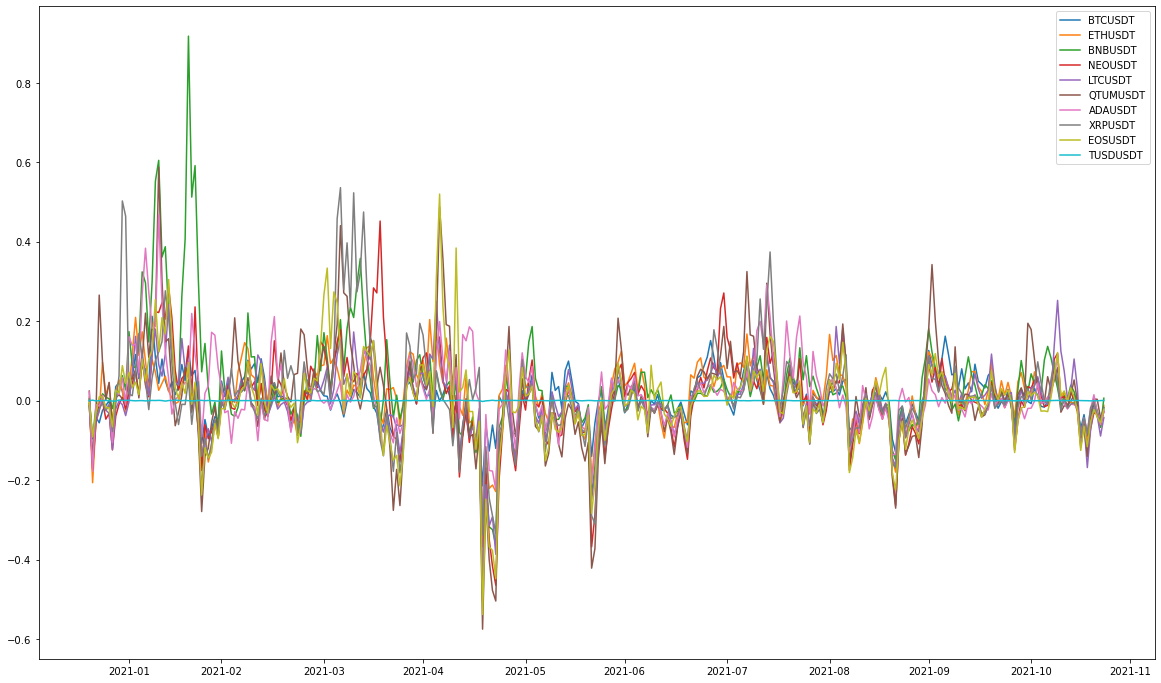

In [4]:
# make value functions
samples = dict()
gamma = 0.9
for coin in original_samples.keys():
    sample = original_samples[coin].copy()
    sample['value'] = 0.
    
    for idx in sample.index:
        if idx == sample.index[0]:
            sample.loc[idx, 'value'] = sample.loc[idx, 'log_reward']
            continue
        
        # log_rtn = sample.loc[idx, 'log_reward'] if sample.loc[idx, 'momentum'] > 0. else 0.
        log_rtn = sample.loc[idx, 'log_reward']
        gamma = 1. - 0.5*sample.loc[idx, 'noise']
        sample.loc[idx, 'value'] = log_rtn + gamma*(sample.shift(1).loc[idx, 'value'])
    samples[coin] = sample

plt.figure(figsize=(20, 12))
for coin in list(samples.keys())[:10]:
    plt.plot(samples[coin].index, samples[coin].value, label=coin)
plt.legend(loc='best')
plt.show()

In [5]:
book = samples['BTCUSDT'][['close']].copy()
book['number'] = book.index.map(mdates.date2num)
book['reward'] = 1.
book['value'] = 0.

for idx in ref.index:
    if idx in [ref.index[0], ref.index[-1]]:
        continue
    
    # select 20 highest coins|
    volumes = dict()
    for coin in samples.keys(): 
        try:
            volumes[coin] = samples[coin].loc[idx, 'close'] * samples[coin].loc[idx, 'volume']
            #volumes[coin] = samples[coin].loc[idx, 'MFI']
        except:
            continue
    top20v = dict(sorted(volumes.items(), key=(lambda x: x[1]), reverse=True)[:21])
    
    # make dictionary for the values
    values = dict()
    for coin in top20v.keys():
        try:
            values[coin] = samples[coin].loc[idx, 'value']
        except:
            pass
        
    if len(values) == 0:
        continue
    
    res = dict(sorted(values.items(), key=(lambda x: x[1]), reverse=True)[:5])

    if idx == ref.index[-1]:
        print(res.items())
    value = np.mean(list(res.values()))
    
    #momentums = list()
    #for coin in res.keys():
    #    momentums.append(samples[coin].shift(1).loc[idx, 'momentum'])

    reward = 0.
    for i, coin in enumerate(res.keys()):
        ratio = 1./len(res)
        
        #if samples[coin].loc[idx, 'momentum'] < 0. or samples[coin].loc[idx, 'value'] < samples["BTCUSDT"].loc[idx, 'value']:
        if samples[coin].loc[idx, 'momentum'] < 0.3:
            reward += ratio
        else:
            reward += ratio*(samples[coin].shift(-1).loc[idx, 'return']-0.003)
        
    book.loc[idx, 'reward'] = reward
    book.loc[idx, 'value'] = value
book.dropna(inplace=True)
book.tail(20)

,close,number,reward,value
datetime,,,,
2021-11-04,61395.01,18935.0,0.989486,0.280029
2021-11-05,60937.12,18936.0,1.022950,0.207736
2021-11-06,61470.61,18937.0,0.975471,0.160232
2021-11-07,63273.59,18938.0,0.991788,0.198349
2021-11-08,67525.83,18939.0,1.078412,0.238961
2021-11-09,66947.66,18940.0,1.005143,0.292594
2021-11-10,64882.43,18941.0,0.960861,0.372356
2021-11-11,64774.26,18942.0,1.001624,0.309985
2021-11-12,64122.23,18943.0,0.986194,0.225640


==== value trading ====
Accumulated Returns: 1141.58 %
CAGR: 1878.93 %
MDD: -29.83 %
VOL: 139.159 %
Sharpe: 26509.45 %


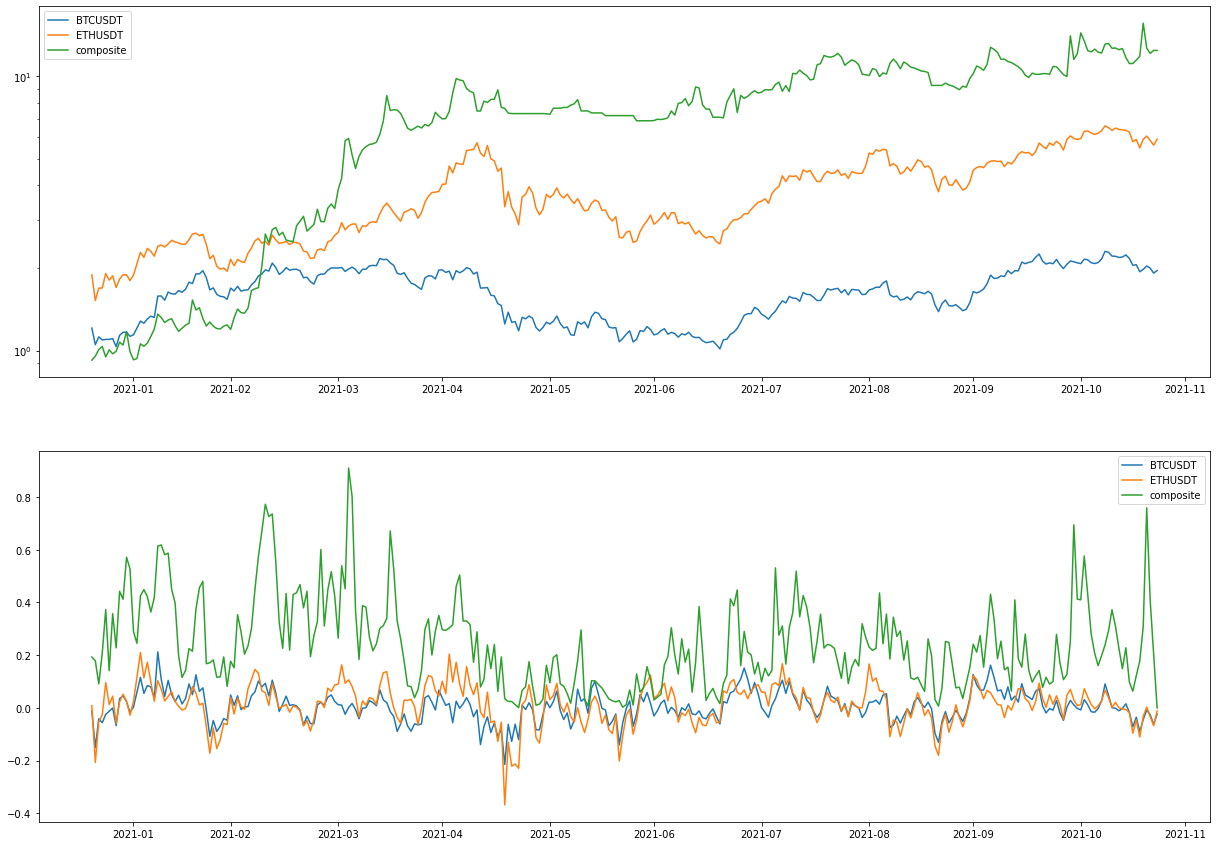

In [6]:
# evaluate
total_reward = 1.
for idx in book.index:
    total_reward *= book.loc[idx, 'reward']
    book.loc[idx, 'total_reward'] = total_reward
CAGR = book['total_reward'].iloc[-1]**(365./len(book.index)) - 1.

historical_max = book['total_reward'].cummax()
daily_drawdown = book['total_reward']/historical_max - 1.
historical_dd = daily_drawdown.cummin()
MDD = historical_dd.min()
VOL = np.std(book['reward'])*np.sqrt(365.)                                     # 주가의 변동폭은 시간의 제곱근에 비례
Sharpe = (np.mean(book['reward'])/np.std(book['reward'])*np.sqrt(365.))       # 연율화된 sharpe ratio # unacceptable

print("==== value trading ====")
print("Accumulated Returns:", round((total_reward-1.)*100, 2), "%")
print("CAGR:", round(CAGR*100, 2), "%")
print("MDD:", round(MDD*100, 2), "%")
print("VOL:", round(VOL*100, 3), "%")
print("Sharpe:", round(Sharpe*100,2), "%")

plt.figure(figsize=(21, 15))
plt.subplot(2, 1, 1)
plt.yscale('log')
#for coin in samples.keys():
#    plt.plot(samples[coin].index, samples[coin].total_reward, label=coin)
plt.plot(samples['BTCUSDT'].index, samples['BTCUSDT'].total_reward, label="BTCUSDT")
plt.plot(samples['ETHUSDT'].index, samples['ETHUSDT'].total_reward, label="ETHUSDT")
plt.plot(book.index, book.total_reward, label='composite')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.plot(samples['BTCUSDT'].index, samples['BTCUSDT'].value, label="BTCUSDT")
plt.plot(samples['ETHUSDT'].index, samples['ETHUSDT'].value, label="ETHUSDT")
plt.plot(book.index, book.value, label="composite")
plt.legend(loc='best')

plt.show()